In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.datasets import mnist

In [2]:
# ── activations.py ──
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def softmax(z):
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# ── losses.py ──
def cross_entropy_loss(y_pred, y_true):
    n = y_pred.shape[0]
    log_likelihood = -np.log(np.clip(y_pred[range(n), y_true], 1e-12, 1.0))
    return np.mean(log_likelihood)

def cross_entropy_derivative(y_pred, y_true):
    n = y_pred.shape[0]
    grad = y_pred.copy()
    grad[range(n), y_true] -= 1
    return grad / n

# ── optimizers.py ──
class SGD:
    def __init__(self, learning_rate=0.01):
        self.lr = learning_rate

    def update(self, weights, biases, dW, dB):
        for i in range(len(weights)):
            weights[i] -= self.lr * dW[i]
            biases[i]  -= self.lr * dB[i]

class Adam:
    def __init__(self, learning_rate=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0
        self.m_w = self.v_w = self.m_b = self.v_b = None

    def update(self, weights, biases, dW, dB):
        if self.m_w is None:
            self.m_w = [np.zeros_like(w) for w in weights]
            self.v_w = [np.zeros_like(w) for w in weights]
            self.m_b = [np.zeros_like(b) for b in biases]
            self.v_b = [np.zeros_like(b) for b in biases]
        self.t += 1
        for i in range(len(weights)):
            self.m_w[i] = self.beta1 * self.m_w[i] + (1 - self.beta1) * dW[i]
            self.m_b[i] = self.beta1 * self.m_b[i] + (1 - self.beta1) * dB[i]
            self.v_w[i] = self.beta2 * self.v_w[i] + (1 - self.beta2) * dW[i]**2
            self.v_b[i] = self.beta2 * self.v_b[i] + (1 - self.beta2) * dB[i]**2
            m_w_hat = self.m_w[i] / (1 - self.beta1**self.t)
            m_b_hat = self.m_b[i] / (1 - self.beta1**self.t)
            v_w_hat = self.v_w[i] / (1 - self.beta2**self.t)
            v_b_hat = self.v_b[i] / (1 - self.beta2**self.t)
            weights[i] -= self.lr * m_w_hat / (np.sqrt(v_w_hat) + self.epsilon)
            biases[i]  -= self.lr * m_b_hat / (np.sqrt(v_b_hat) + self.epsilon)

# ── network.py ──
class MLP:
    def __init__(self, layer_sizes, optimizer=None):
        self.layer_sizes = layer_sizes
        self.weights = []
        self.biases = []
        self.optimizer = optimizer
        self._init_weights()

    def _init_weights(self):
        for i in range(len(self.layer_sizes) - 1):
            fan_in = self.layer_sizes[i]
            w = np.random.randn(fan_in, self.layer_sizes[i+1]) * np.sqrt(2.0 / fan_in)
            b = np.zeros((1, self.layer_sizes[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def forward(self, X):
        self.activations = [X]
        self.z_values = []
        for i in range(len(self.weights) - 1):
            z = self.activations[-1] @ self.weights[i] + self.biases[i]
            self.z_values.append(z)
            self.activations.append(relu(z))
        z_out = self.activations[-1] @ self.weights[-1] + self.biases[-1]
        self.z_values.append(z_out)
        self.activations.append(softmax(z_out))
        return self.activations[-1]

    def backward(self, y_true):
        n_layers = len(self.weights)
        dW = [None] * n_layers
        dB = [None] * n_layers
        delta = cross_entropy_derivative(self.activations[-1], y_true)
        for i in reversed(range(n_layers)):
            dW[i] = self.activations[i].T @ delta
            dB[i] = np.sum(delta, axis=0, keepdims=True)
            if i > 0:
                delta = delta @ self.weights[i].T * relu_derivative(self.z_values[i-1])
        return dW, dB

    def train(self, X, y, epochs, batch_size):
        loss_history, acc_history = [], []
        n = X.shape[0]
        for epoch in range(epochs):
            indices = np.random.permutation(n)
            X, y = X[indices], y[indices]
            for start in range(0, n, batch_size):
                X_batch = X[start:start+batch_size]
                y_batch = y[start:start+batch_size]
                self.forward(X_batch)
                dW, dB = self.backward(y_batch)
                self.optimizer.update(self.weights, self.biases, dW, dB)
            y_pred = self.forward(X)
            loss = cross_entropy_loss(y_pred, y)
            acc = np.mean(np.argmax(y_pred, axis=1) == y)
            loss_history.append(loss)
            acc_history.append(acc)
            print(f"Época {epoch+1}/{epochs} — Loss: {loss:.4f} — Acurácia: {acc:.4f}")
        return loss_history, acc_history

    def predict(self, X):
        return np.argmax(self.forward(X), axis=1)

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.reshape(-1, 784).astype(np.float32) / 255.0
X_test  = X_test.reshape(-1, 784).astype(np.float32) / 255.0

print(f"Treino: {X_train.shape}, Teste: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Treino: (60000, 784), Teste: (10000, 784)


In [4]:
model_sgd = MLP(layer_sizes=[784, 256, 128, 10], optimizer=SGD(learning_rate=0.01))
loss_sgd, acc_sgd = model_sgd.train(X_train, y_train, epochs=20, batch_size=64)

acc_teste_sgd = np.mean(model_sgd.predict(X_test) == y_test)
print(f"\nAcurácia no teste (SGD): {acc_teste_sgd:.4f}")

Época 1/20 — Loss: 0.3809 — Acurácia: 0.8951
Época 2/20 — Loss: 0.2998 — Acurácia: 0.9141
Época 3/20 — Loss: 0.2574 — Acurácia: 0.9265
Época 4/20 — Loss: 0.2350 — Acurácia: 0.9325
Época 5/20 — Loss: 0.2108 — Acurácia: 0.9407
Época 6/20 — Loss: 0.1968 — Acurácia: 0.9436
Época 7/20 — Loss: 0.1823 — Acurácia: 0.9480
Época 8/20 — Loss: 0.1685 — Acurácia: 0.9519
Época 9/20 — Loss: 0.1555 — Acurácia: 0.9563
Época 10/20 — Loss: 0.1459 — Acurácia: 0.9590
Época 11/20 — Loss: 0.1373 — Acurácia: 0.9614
Época 12/20 — Loss: 0.1310 — Acurácia: 0.9628
Época 13/20 — Loss: 0.1230 — Acurácia: 0.9653
Época 14/20 — Loss: 0.1162 — Acurácia: 0.9674
Época 15/20 — Loss: 0.1110 — Acurácia: 0.9694
Época 16/20 — Loss: 0.1047 — Acurácia: 0.9708
Época 17/20 — Loss: 0.1003 — Acurácia: 0.9725
Época 18/20 — Loss: 0.0949 — Acurácia: 0.9735
Época 19/20 — Loss: 0.0921 — Acurácia: 0.9743
Época 20/20 — Loss: 0.0881 — Acurácia: 0.9758

Acurácia no teste (SGD): 0.9666


In [5]:
model_adam = MLP(layer_sizes=[784, 256, 128, 10], optimizer=Adam(learning_rate=0.001))
loss_adam, acc_adam = model_adam.train(X_train, y_train, epochs=20, batch_size=64)

acc_teste_adam = np.mean(model_adam.predict(X_test) == y_test)
print(f"\nAcurácia no teste (Adam): {acc_teste_adam:.4f}")

Época 1/20 — Loss: 0.1002 — Acurácia: 0.9689
Época 2/20 — Loss: 0.0596 — Acurácia: 0.9808
Época 3/20 — Loss: 0.0492 — Acurácia: 0.9839
Época 4/20 — Loss: 0.0404 — Acurácia: 0.9869
Época 5/20 — Loss: 0.0225 — Acurácia: 0.9930
Época 6/20 — Loss: 0.0219 — Acurácia: 0.9925
Época 7/20 — Loss: 0.0236 — Acurácia: 0.9918
Época 8/20 — Loss: 0.0166 — Acurácia: 0.9944
Época 9/20 — Loss: 0.0104 — Acurácia: 0.9964
Época 10/20 — Loss: 0.0238 — Acurácia: 0.9929
Época 11/20 — Loss: 0.0105 — Acurácia: 0.9965
Época 12/20 — Loss: 0.0072 — Acurácia: 0.9976
Época 13/20 — Loss: 0.0100 — Acurácia: 0.9970
Época 14/20 — Loss: 0.0048 — Acurácia: 0.9985
Época 15/20 — Loss: 0.0046 — Acurácia: 0.9986
Época 16/20 — Loss: 0.0066 — Acurácia: 0.9979
Época 17/20 — Loss: 0.0055 — Acurácia: 0.9985
Época 18/20 — Loss: 0.0027 — Acurácia: 0.9991
Época 19/20 — Loss: 0.0053 — Acurácia: 0.9983
Época 20/20 — Loss: 0.0045 — Acurácia: 0.9984

Acurácia no teste (Adam): 0.9810


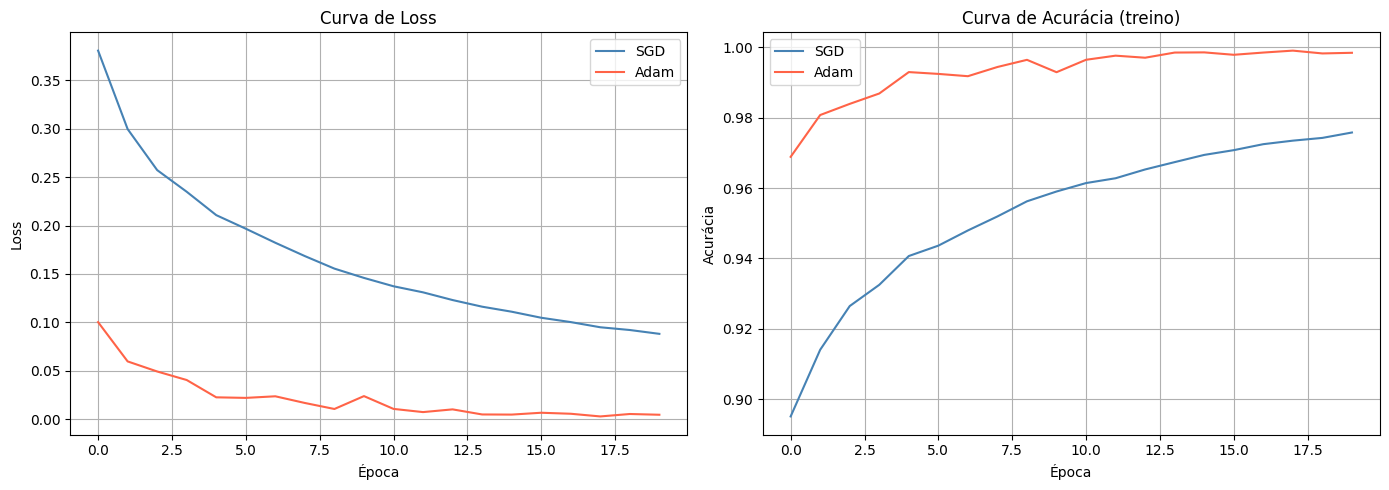

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(loss_sgd, label='SGD', color='steelblue')
ax1.plot(loss_adam, label='Adam', color='tomato')
ax1.set_title('Curva de Loss')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(acc_sgd, label='SGD', color='steelblue')
ax2.plot(acc_adam, label='Adam', color='tomato')
ax2.set_title('Curva de Acurácia (treino)')
ax2.set_xlabel('Época')
ax2.set_ylabel('Acurácia')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('loss_accuracy.png', dpi=150)
plt.show()

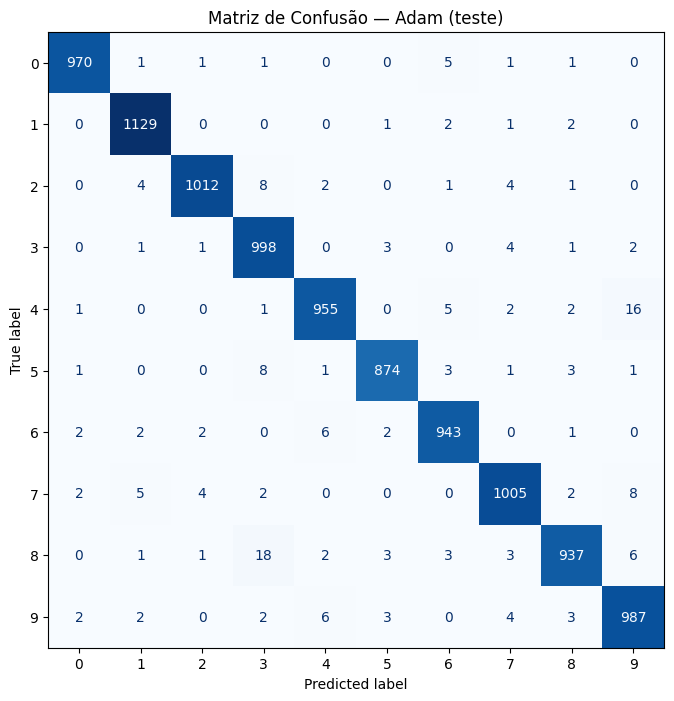

In [7]:
y_pred_adam = model_adam.predict(X_test)

cm = confusion_matrix(y_test, y_pred_adam)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matriz de Confusão — Adam (teste)')
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

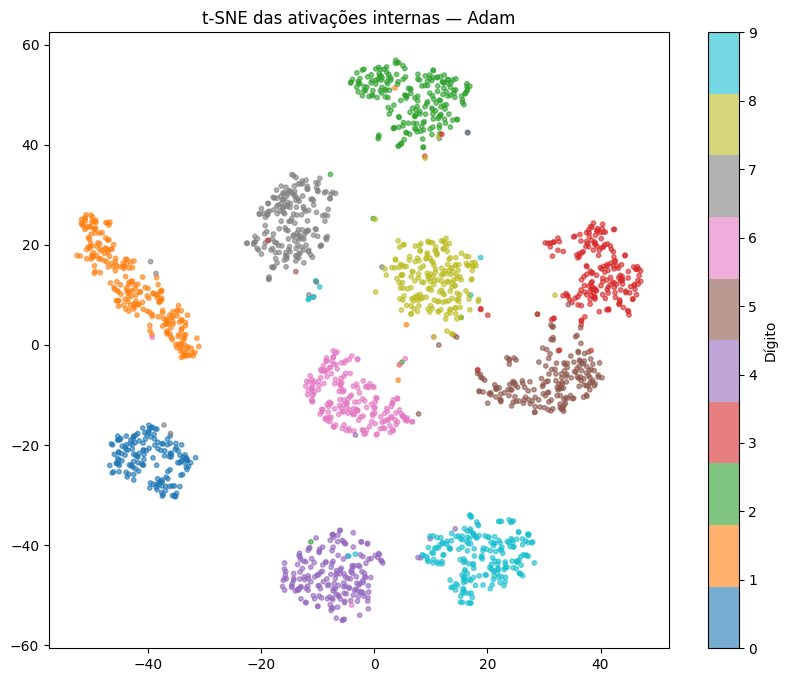

In [8]:
idx = np.random.choice(len(X_test), 2000, replace=False)
X_sample = X_test[idx]
y_sample = y_test[idx]

model_adam.forward(X_sample)
embeddings = model_adam.activations[-2]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(embeddings)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_sample, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(scatter, ticks=range(10), label='Dígito')
plt.title('t-SNE das ativações internas — Adam')
plt.savefig('tsne.png', dpi=150)
plt.show()

In [9]:
def gradient_check(X_sample, y_sample, epsilon=1e-5):
    model_check = MLP(layer_sizes=[784, 32, 10], optimizer=SGD(0.01))
    model_check.forward(X_sample)
    dW, dB = model_check.backward(y_sample)

    i, j = 0, 0
    analytic_grad = dW[0][i, j]

    model_check.weights[0][i, j] += epsilon
    loss_plus = cross_entropy_loss(model_check.forward(X_sample), y_sample)

    model_check.weights[0][i, j] -= 2 * epsilon
    loss_minus = cross_entropy_loss(model_check.forward(X_sample), y_sample)

    model_check.weights[0][i, j] += epsilon

    numeric_grad = (loss_plus - loss_minus) / (2 * epsilon)
    diff = abs(analytic_grad - numeric_grad) / (abs(analytic_grad) + abs(numeric_grad) + 1e-8)

    print(f"Gradiente analítico:  {analytic_grad:.8f}")
    print(f"Gradiente numérico:   {numeric_grad:.8f}")
    print(f"Diferença relativa:   {diff:.2e}")
    print("✅ Gradientes corretos!" if diff < 1e-5 else "❌ Gradientes errados!")

gradient_check(X_train[:16], y_train[:16])

Gradiente analítico:  0.00000000
Gradiente numérico:   0.00000000
Diferença relativa:   0.00e+00
✅ Gradientes corretos!


In [11]:
np.random.seed(42)
X_rand = np.random.randn(16, 784)
y_rand = np.random.randint(0, 10, 16)

for i, j in [(0,0), (1,5), (10,15), (100,20)]:
    model_check = MLP(layer_sizes=[784, 32, 10], optimizer=SGD(0.01))
    model_check.forward(X_rand)
    dW, dB = model_check.backward(y_rand)

    analytic_grad = dW[0][i, j]
    epsilon = 1e-5

    model_check.weights[0][i, j] += epsilon
    loss_plus = cross_entropy_loss(model_check.forward(X_rand), y_rand)
    model_check.weights[0][i, j] -= 2 * epsilon
    loss_minus = cross_entropy_loss(model_check.forward(X_rand), y_rand)
    model_check.weights[0][i, j] += epsilon

    numeric_grad = (loss_plus - loss_minus) / (2 * epsilon)
    diff = abs(analytic_grad - numeric_grad) / (abs(analytic_grad) + abs(numeric_grad) + 1e-8)

    print(f"[{i},{j}] analítico={analytic_grad:.6f} | numérico={numeric_grad:.6f} | diff={diff:.2e} {'✅' if diff < 1e-5 else '❌'}")

[0,0] analítico=0.042804 | numérico=0.042804 | diff=9.87e-11 ✅
[1,5] analítico=-0.022849 | numérico=-0.022849 | diff=3.41e-10 ✅
[10,15] analítico=-0.046879 | numérico=-0.046879 | diff=1.71e-10 ✅
[100,20] analítico=-0.026399 | numérico=-0.026399 | diff=2.60e-10 ✅


In [12]:
from google.colab import files

files.download('loss_accuracy.png')
files.download('confusion_matrix.png')
files.download('tsne.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>